# BirdCLEF+ 2026 — Baseline Training

The simplest end-to-end pipeline that produces a working `submission.csv`:

audio file → 5-second slice → mel spectrogram → CNN classifier → 234 species probabilities

Read each cell, run it (`Shift+Enter`), look at the output, **then** read the next cell.
The whole notebook is designed to be re-run top to bottom.

**Tip:** Start with `DEBUG = True` further down — that trains on a tiny subset (10 species, ~500 clips)
so you can see the full loop in ~10 minutes on CPU before committing to a long run.


## 1. Imports & device

`torch` is the deep learning library. `timm` gives us pretrained image models.
`librosa` and `soundfile` handle audio. `sklearn` gives us the validation metric.


In [52]:
import os, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import librosa
import soundfile as sf
import timm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Pick the best available device:
#   cuda   = NVIDIA GPU
#   mps    = Apple Silicon GPU (M1/M2/M3)
#   cpu    = fallback
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)
print("Torch :", torch.__version__)


Device: mps
Torch : 2.12.0


## 2. Configuration

All hyperparameters live in one place. Change them here, not deep in the code below.

A **hyperparameter** is a knob *you* set before training, vs. a "parameter" which is
something the model learns. Things like learning rate, batch size, and how many
epochs to train are hyperparameters.


In [85]:
# ---- Paths ------------------------------------------------------------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data" / "birdclef-2026"
TRAIN_CSV    = DATA_DIR / "train.csv"
TRAIN_AUDIO  = DATA_DIR / "train_audio"
CKPT_DIR     = PROJECT_ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

assert TRAIN_CSV.exists(), f"Missing {TRAIN_CSV}. Did you unzip the data?"

# ---- Audio / mel-spectrogram settings --------------------------------
# Keep these identical between training and inference, or the model will
# see "different-looking pictures" at inference time and perform poorly.
SR          = 32000          # sample rate (the competition uses 32 kHz)
CLIP_SEC    = 5              # length of one training slice, in seconds
N_SAMPLES   = SR * CLIP_SEC  # 160,000 audio samples per slice
N_MELS      = 128            # vertical resolution of the spectrogram
N_FFT       = 2048           # FFT window size — controls frequency precision
HOP_LENGTH  = 512            # step between FFT windows — controls time resolution
FMIN, FMAX  = 20, 16000      # mel frequency range (Hz)

# ---- Training settings ------------------------------------------------
DEBUG        = True          # <-- start here. Flip to False for the full run.
BATCH_SIZE   = 32
EPOCHS       = 8
LR           = 1e-3          # learning rate: how big a step we take each update
NUM_WORKERS  = 0             # Jupyter on macOS: must be 0 (class pickling fails for notebook-defined classes). Set >0 only when running as a .py script.
SEED         = 42
BACKBONE     = "efficientnet_b0"   # small pretrained image model from `timm`

# ---- Determinism: seed all the random number generators --------------
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"DEBUG mode: {DEBUG}")
print(f"Data dir:   {DATA_DIR}")


DEBUG mode: True
Data dir:   /Users/harish.r/Documents/kaggle/birdclef2026/data/birdclef-2026


## 3. Load metadata

`train.csv` is the table of (clip filename, species label). Let's peek.


In [54]:
df = pd.read_csv(TRAIN_CSV)
print(f"Rows: {len(df):,}   Unique species (primary_label): {df['primary_label'].nunique()}")
df[["filename", "primary_label", "secondary_labels", "common_name", "class_name"]].head(5)


Rows: 35,549   Unique species (primary_label): 206


,filename,primary_label,secondary_labels,common_name,class_name
0,1161364/iNat1216197.ogg,1161364,[],Guyalna cuta,Insecta
1,1161364/iNat1114648.ogg,1161364,[],Guyalna cuta,Insecta
2,1161364/iNat810195.ogg,1161364,[],Guyalna cuta,Insecta
3,1161364/iNat818781.ogg,1161364,[],Guyalna cuta,Insecta
4,1161364/iNat556514.ogg,1161364,[],Guyalna cuta,Insecta


A few things to notice:

- **`filename`** is relative to `train_audio/` — e.g. `1161364/iNat1216197.ogg`.
- **`primary_label`** is the species ID (the integer iNaturalist taxon ID, stored as a string).
- **`secondary_labels`** can list additional species in the same clip. We'll ignore those for now
  to keep things simple — but in a multi-label setting like this, they're free positive labels.
- **`class_name`** says it's not all birds — there are insects, reptiles, mammals, amphibians too.

The taxonomy lists 234 species, but only ~206 have any training audio. Some species we'll
predict are essentially "zero-shot" — the model never saw them.


In [55]:
# Map each species ID to an index 0..N-1.
# The model will output N numbers in this order; we need this mapping to know
# "the 47th number is for species X".
df = df[["filename", "primary_label"]].copy()
df["primary_label"] = df["primary_label"].astype(str)

if DEBUG:
    # Keep only 10 species, max 50 clips each — fast smoke test.
    keep_species = df["primary_label"].value_counts().head(10).index
    df = df[df["primary_label"].isin(keep_species)].groupby("primary_label").head(50).reset_index(drop=True)
    print(f"[DEBUG] Reduced to {len(df)} clips across {df['primary_label'].nunique()} species.")

species      = sorted(df["primary_label"].unique())
label_to_idx = {s: i for i, s in enumerate(species)}
NUM_CLASSES  = len(species)
# print(df)
print(f"NUM_CLASSES = {NUM_CLASSES}")


[DEBUG] Reduced to 500 clips across 10 species.
NUM_CLASSES = 10


## 4. Audio helpers

Three small functions:

1. **`load_audio`** — read an .ogg file into a 1D array of floats at 32 kHz.
2. **`take_random_5s`** — pad if short, randomly crop if long. Random cropping is **data
   augmentation**: each epoch sees a different 5s window of the same clip, which
   helps the model generalize.
3. **`wav_to_mel`** — turn the waveform into a 2D mel spectrogram ("picture of sound").
   Then convert to decibels (a more visual scale) and normalize.


In [56]:
def load_audio(path):
    """Load an audio file as float32 mono at 32 kHz."""
    wav, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = wav.mean(axis=1)                 # stereo -> mono
    if sr != SR:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=SR)
    return wav.astype(np.float32)


def take_random_5s(wav):
    """Pad short clips with silence; randomly crop longer clips to 5s."""
    if len(wav) < N_SAMPLES:
        wav = np.pad(wav, (0, N_SAMPLES - len(wav)))
    elif len(wav) > N_SAMPLES:
        start = np.random.randint(0, len(wav) - N_SAMPLES + 1)
        wav   = wav[start:start + N_SAMPLES]
    return wav


def wav_to_mel(wav):
    """Waveform -> log-mel spectrogram, normalized to ~N(0, 1). Shape: (N_MELS, time_frames)."""
    mel    = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX, power=2.0,
    )
    mel_db = librosa.power_to_db(mel, top_db=80)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    return mel_db.astype(np.float32)


## 5. Sanity check — look at one mel spectrogram

Run this cell several times — the random crop means you'll see different views of the same clip.
Brighter regions = more energy at that frequency at that moment.


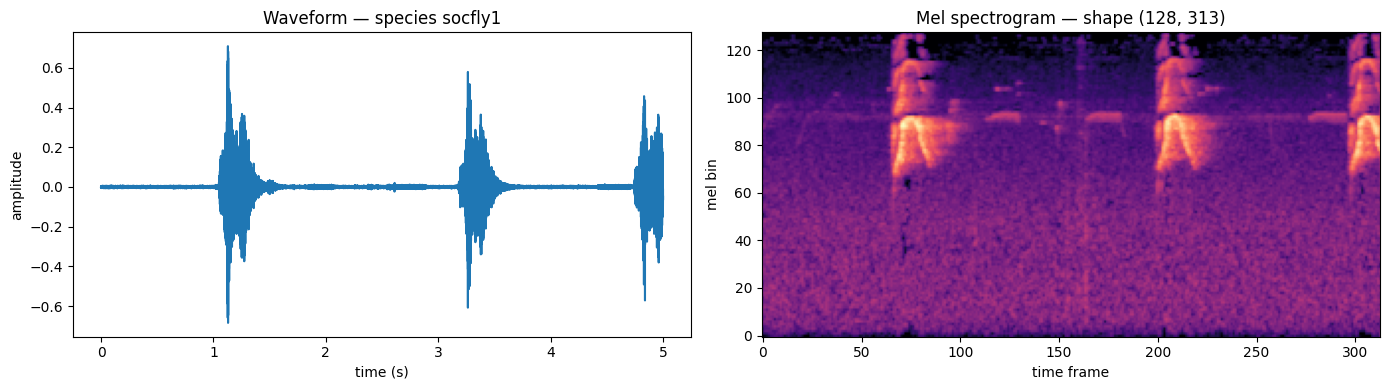

File: socfly1/XC469247.ogg, duration: 8.8s


In [57]:
sample = df.sample(1).iloc[0]
path   = TRAIN_AUDIO / sample["filename"]
wav    = load_audio(path)
wav5   = take_random_5s(wav)
mel    = wav_to_mel(wav5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.linspace(0, CLIP_SEC, len(wav5)), wav5)
axes[0].set_title(f"Waveform — species {sample['primary_label']}")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("amplitude")
axes[1].imshow(mel, origin="lower", aspect="auto", cmap="magma")
axes[1].set_title(f"Mel spectrogram — shape {mel.shape}")
axes[1].set_xlabel("time frame"); axes[1].set_ylabel("mel bin")
plt.tight_layout(); plt.show()
print(f"File: {sample['filename']}, duration: {len(wav)/SR:.1f}s")


## 6. PyTorch `Dataset`

A `Dataset` is just an object that answers two questions:

- `len(ds)` — how many examples do you have?
- `ds[i]`  — give me the i-th example as `(mel, label)`.

PyTorch's `DataLoader` will use this in parallel across `NUM_WORKERS` processes
to feed the model batches of examples during training.


In [58]:
class BirdDataset(Dataset):
    def __init__(self, df, training=True):
        self.df       = df.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row  = self.df.iloc[i]
        path = TRAIN_AUDIO / row["filename"]
        try:
            wav = load_audio(path)
        except Exception as e:
            # If a file is corrupt, return silence — don't crash the run.
            print(f"[warn] failed to load {path}: {e}")
            wav = np.zeros(N_SAMPLES, dtype=np.float32)

        wav = take_random_5s(wav)
        mel = wav_to_mel(wav)
        # Add a "channel" dim up front: image models expect (channels, height, width).
        mel = torch.from_numpy(mel).unsqueeze(0)

        # One-hot label vector. We use one-hot (not a single int) because we use
        # BCEWithLogitsLoss, which treats each species as an independent yes/no question.
        # This generalizes to multi-label later (when we use secondary_labels too).
        label_vec = torch.zeros(NUM_CLASSES, dtype=torch.float32)
        label_vec[label_to_idx[row["primary_label"]]] = 1.0
        return mel, label_vec


# Verify it works: ask for one example and check shapes.
_ds = BirdDataset(df.head(3))
mel0, lbl0 = _ds[0]
print(f"mel shape: {tuple(mel0.shape)}    label shape: {tuple(lbl0.shape)}    label sum: {lbl0.sum()}")


mel shape: (1, 128, 313)    label shape: (10,)    label sum: 1.0


## 7. Train / validation split

We hold out ~15% of clips as a **validation set** — we never train on these.
After every epoch we measure how well the model does on the val set; that tells us
whether the model is actually learning generalizable patterns vs. memorizing.

We **stratify** the split by species so each species appears proportionally in both sets.


In [59]:
counts        = df["primary_label"].value_counts()
rare_species  = counts[counts < 2].index            # can't stratify singletons
rare_rows     = df[df["primary_label"].isin(rare_species)]
splittable    = df[~df["primary_label"].isin(rare_species)]

train_df, val_df = train_test_split(
    splittable, test_size=0.15, random_state=SEED, stratify=splittable["primary_label"],
)
train_df = pd.concat([train_df, rare_rows], ignore_index=True)
print(f"Train: {len(train_df):,}    Val: {len(val_df):,}")


Train: 425    Val: 75


## 8. DataLoaders

The `DataLoader` batches examples together (`BATCH_SIZE` at a time) and shuffles
each epoch. GPUs love processing many examples in parallel — much faster than
one at a time.


In [86]:
train_ds = BirdDataset(train_df, training=True)
val_ds   = BirdDataset(val_df,   training=False)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
print(f"Train batches: {len(train_loader)}   Val batches: {len(val_loader)}")


Train batches: 14   Val batches: 3


## 9. The model

`timm` is a library of pretrained image classifiers. We use **efficientnet_b0** — small,
fast, ~5M parameters. Two key tweaks:

- **`in_chans=1`** — mel spectrograms are grayscale, not RGB.
- **`num_classes=NUM_CLASSES`** — final layer outputs one number per species.
- **`pretrained=True`** — start with knobs already trained on millions of regular photos
  (ImageNet). Those knobs already know about edges, textures, shapes, and that
  transfers surprisingly well to spectrograms. This is called **transfer learning**.


In [87]:
model     = timm.create_model(BACKBONE, pretrained=True, in_chans=1, num_classes=NUM_CLASSES)
model     = model.to(DEVICE)
n_params  = sum(p.numel() for p in model.parameters())
print(f"Model: {BACKBONE} | params: {n_params/1e6:.1f}M | classes: {NUM_CLASSES}")


Model: efficientnet_b0 | params: 4.0M | classes: 10


## 10. Loss & optimizer

- **Loss function** = how wrong was the model? A single number. Training minimizes it.
  We use **Binary Cross-Entropy with Logits** because each species is an independent
  yes/no question (multi-label, not multi-class).
- **Optimizer** = how to adjust the knobs given the gradients. **Adam** is the
  default that works well almost everywhere; LR controls step size.


In [62]:
loss_fn   = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


## 11. Validation metric

We measure **macro-averaged AUC**: for each species, compute the AUC between
the true labels and predicted probabilities, then average. AUC ranges from 0.5
(random) to 1.0 (perfect). "Macro" means each species counts equally regardless
of how often it appears.


In [88]:
def macro_auc(y_true, y_pred):
    scores = []
    for c in range(y_true.shape[1]):
        col = y_true[:, c]
        if col.sum() == 0 or col.sum() == len(col):
            continue   # AUC undefined if all labels are 0 or all are 1
        try:
            scores.append(roc_auc_score(col, y_pred[:, c]))
        except ValueError:
            continue
    return float(np.mean(scores)) if scores else float("nan")


## 12. Train & validate functions

Each training step:

1. Pull a batch (mels, labels) onto the device.
2. **Forward pass**: feed mels through the model → get logits (raw scores).
3. **Loss**: how wrong are the logits compared to the labels?
4. **Backward pass**: PyTorch computes gradients automatically.
5. **Step**: optimizer nudges each knob in the direction that reduces loss.

Validation is the same but without steps 3–5 — we just collect predictions
and compute AUC at the end. `@torch.no_grad()` tells PyTorch not to track
gradients (faster, less memory).


In [64]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for mel, label in pbar:
        mel, label = mel.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        logits = model(mel)
        loss   = loss_fn(logits, label)
        loss.backward()
        optimizer.step()
        total += loss.item(); n += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total / max(1, n)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for mel, label in tqdm(loader, desc="val", leave=False):
        mel    = mel.to(DEVICE)
        logits = model(mel).cpu().numpy()
        all_logits.append(logits); all_labels.append(label.numpy())
    y_pred = np.concatenate(all_logits)
    y_true = np.concatenate(all_labels)
    y_prob = 1.0 / (1.0 + np.exp(-y_pred))   # sigmoid -> probability
    return macro_auc(y_true, y_prob)


## 13. Train loop

Each epoch = one full pass over the training data. After each epoch we measure
validation AUC and save the model if it's the best so far.

You should see:
- **`loss`** going down each epoch (model getting less wrong).
- **`val_auc`** going up (model generalizing better).

If `val_auc` starts going *down* while loss keeps dropping, the model is **overfitting**
— memorizing the train set instead of learning patterns. That's a signal to stop earlier.


In [89]:
best_auc  = -1.0
ckpt_path = CKPT_DIR / ("model_debug.pt" if DEBUG else "model.pt")

for epoch in range(1, EPOCHS + 1):
    t0         = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_auc    = validate(model, val_loader)
    dt         = time.time() - t0

    flag = ""
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save({
            "state_dict":   model.state_dict(),
            "species":      species,
            "label_to_idx": label_to_idx,
            "backbone":     BACKBONE,
            "num_classes":  NUM_CLASSES,
            "sr":           SR,
            "n_mels":       N_MELS,
            "n_fft":        N_FFT,
            "hop_length":   HOP_LENGTH,
            "fmin":         FMIN,
            "fmax":         FMAX,
            "clip_sec":     CLIP_SEC,
        }, ckpt_path)
        flag = "  <- new best, saved"

    print(f"Epoch {epoch:2d}/{EPOCHS}  loss={train_loss:.4f}  val_auc={val_auc:.4f}  ({dt:.1f}s){flag}")

print(f"\nBest val AUC: {best_auc:.4f}")
print(f"Checkpoint:   {ckpt_path}")


train:   0%|          | 0/14 [00:00<?, ?it/s]

val:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch  1/8  loss=1.5553  val_auc=0.5118  (22.6s)  <- new best, saved


train:   0%|          | 0/14 [00:00<?, ?it/s]

val:   0%|          | 0/3 [00:00<?, ?it/s]

...

val:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch  7/8  loss=1.5454  val_auc=0.4701  (12.4s)


train:   0%|          | 0/14 [00:00<?, ?it/s]

val:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch  8/8  loss=1.5392  val_auc=0.4999  (12.4s)

Best val AUC: 0.5462
Checkpoint:   /Users/harish.r/Documents/kaggle/birdclef2026/checkpoints/model_debug.pt


## What just happened

You trained a CNN to recognize bird species from 5-second audio clips.
The model:

1. Sees mel spectrograms ("pictures of sound").
2. Outputs 234 numbers per clip (one logit per species).
3. Learned by adjusting its millions of knobs to make those numbers match the true labels.

**Next step:** open `02_infer.ipynb` to load this checkpoint, run it on the soundscapes,
and write a `submission.csv`.

## Ideas to improve from here

In rough order of cost/benefit:

1. **Use the full data** — flip `DEBUG = False` and train on all 234 species.
2. **Train longer** — bump `EPOCHS` from 8 to 20-30. Watch val_auc; stop when it plateaus.
3. **Use secondary_labels** — multi-label your one-hot vector to include all species in a clip (free positive examples).
4. **Audio augmentation** — add background noise, random gain, pitch shift.
5. **Use the labeled soundscapes** — `train_soundscapes_labels.csv` has 60s soundscapes labeled per-window. That's closer to the test distribution than isolated training clips.
6. **Bigger backbone** — try `efficientnet_b1` or `resnet34`. Slower, better.
7. **K-fold ensemble** — train 5 models on different splits, average their predictions.
8. **Add Perch embeddings** — like the top notebook does. Big jump in quality.
